# Chapter 65 — Layer Normalization

## Learning goals

By the end of this chapter, you should be able to:

- Explain transformer-style layer normalization across a token vector's features.

- Compute a token vector's mean and population variance manually.

- Apply the normalization formula with epsilon.

- Match a manual implementation with `torch.nn.LayerNorm`.

- Apply layer normalization to `[batch, context, embedding]` tensors.

- Explain why `keepdim=True` enables feature-axis broadcasting.

- Describe the constant-vector special case.

- Distinguish pure normalization from learned affine scale and shift.

- Demonstrate that one batch item's LayerNorm result does not depend on other items.

- Distinguish LayerNorm from whole-tensor normalization and BatchNorm.


## Normalize one position's features

Chapter 64 preserved `[B, T, C]` shapes through residual connections.

Layer normalization also preserves shape while changing feature values.

In the transformer use case, `LayerNorm(C)` computes separate statistics for every `[batch, position]` pair across its `C` embedding features.

For one token vector `v`, pure normalization is:

```text
normalized = (v - mean(v)) / sqrt(variance(v) + epsilon)
```

This operation centers features and controls their scale before any optional learned affine adjustment.


## Mean, variance, and epsilon

The **mean** is the average feature value in one token vector.

The **population variance** is the average squared distance of those features from their mean.

LayerNorm uses this population-style variance rather than the sample variance that divides by one fewer element.

A small positive **epsilon** is added inside the square root to prevent division by zero and improve numerical stability.

Because epsilon remains in the denominator, a nonconstant normalized vector's variance is usually very close to `1` rather than mathematically exact.


## One token vector by hand

The vector `[10, 20, 30, 40]` has mean `25` and population variance `125`.

The first code cell computes each intermediate value directly.


In [1]:
import torch

device = "cpu"
epsilon = 1e-5
token_vector = torch.tensor(
    [10.0, 20.0, 30.0, 40.0],
    dtype=torch.float32,
    device=device,
)

mean = token_vector.mean()
centered_vector = token_vector - mean
squared_deviations = centered_vector.square()
variance = squared_deviations.mean()
standard_deviation = torch.sqrt(variance + epsilon)
normalized_vector = centered_vector / standard_deviation

print("device:", device)
print("token vector:", token_vector)
print("mean:", mean)
print("centered vector:", centered_vector)
print("squared deviations:", squared_deviations)
print("variance:", variance)
print("standard deviation with epsilon:", standard_deviation)
print("normalized vector:", normalized_vector)
print("normalized mean:", normalized_vector.mean())
print("normalized variance:", normalized_vector.var(unbiased=False))

device: cpu
token vector: tensor([10., 20., 30., 40.])
mean: tensor(25.)
centered vector: tensor([-15.,  -5.,   5.,  15.])
squared deviations: tensor([225.,  25.,  25., 225.])
variance: tensor(125.)
standard deviation with epsilon: tensor(11.1803)
normalized vector: tensor([-1.3416, -0.4472,  0.4472,  1.3416])
normalized mean: tensor(2.9802e-08)
normalized variance: tensor(1.)


The centered features `[-15, -5, 5, 15]` average to zero.

Their squared deviations average to `125`, matching `token_vector.var(unbiased=False)`.

Dividing by `sqrt(125 + epsilon)` produces mean near `0` and variance near `1`.


## A reusable manual implementation

The function below normalizes the last dimension and keeps its mean and variance axes as size `1`.

It therefore handles either one vector or a tensor with leading batch and context dimensions.


In [2]:
def manual_layer_norm_last_dimension(
    input_tensor: torch.Tensor,
    epsilon: float = 1e-5,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    if input_tensor.ndim < 1 or input_tensor.shape[-1] < 1:
        raise ValueError("input must have a nonempty final feature dimension.")

    if not torch.is_floating_point(input_tensor):
        raise TypeError("input must use a floating-point dtype.")

    if epsilon <= 0.0:
        raise ValueError("epsilon must be positive.")

    mean = input_tensor.mean(dim=-1, keepdim=True)
    variance = input_tensor.var(dim=-1, unbiased=False, keepdim=True)
    normalized = (input_tensor - mean) / torch.sqrt(variance + epsilon)
    return normalized, mean, variance


manual_result, manual_mean, manual_variance = manual_layer_norm_last_dimension(
    token_vector, epsilon
)
pure_layer_norm = torch.nn.LayerNorm(
    normalized_shape=token_vector.shape[-1],
    eps=epsilon,
    elementwise_affine=False,
).to(device)
torch_result = pure_layer_norm(token_vector)

print("manual mean shape:", manual_mean.shape)
print("manual variance shape:", manual_variance.shape)
print("manual result:", manual_result)
print("PyTorch result:", torch_result)
print("manual and PyTorch match:", torch.allclose(manual_result, torch_result))

manual mean shape: torch.Size([1])
manual variance shape: torch.Size([1])
manual result: tensor([-1.3416, -0.4472,  0.4472,  1.3416])
PyTorch result: tensor([-1.3416, -0.4472,  0.4472,  1.3416])
manual and PyTorch match: True


`elementwise_affine=False` disables learned scale and shift so the comparison tests only normalization.

The manual and built-in results match because both use population variance and the same epsilon.


The component table and one two-panel figure show the shift and rescaling without putting very different numeric ranges on one axis.


feature | original | centered | normalized
-----------------------------------------------
      0 |  10.0000 | -15.0000 |    -1.3416
      1 |  20.0000 |  -5.0000 |    -0.4472
      2 |  30.0000 |   5.0000 |     0.4472
      3 |  40.0000 |  15.0000 |     1.3416


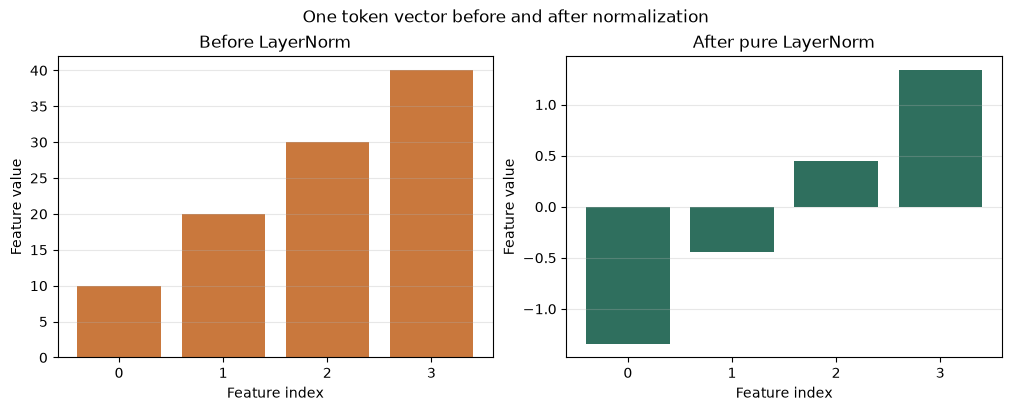

In [3]:
import matplotlib.pyplot as plt

print("feature | original | centered | normalized")
print("-" * 47)
for feature_index in range(token_vector.shape[-1]):
    print(
        f"{feature_index:>7} | "
        f"{token_vector[feature_index].item():>8.4f} | "
        f"{centered_vector[feature_index].item():>8.4f} | "
        f"{normalized_vector[feature_index].item():>10.4f}"
    )

figure, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
feature_indexes = list(range(token_vector.shape[-1]))
axes[0].bar(feature_indexes, token_vector.detach().tolist(), color="#c9783d")
axes[0].set_title("Before LayerNorm")
axes[1].bar(feature_indexes, normalized_vector.detach().tolist(), color="#2f6f5e")
axes[1].set_title("After pure LayerNorm")
for axis in axes:
    axis.set_xlabel("Feature index")
    axis.set_ylabel("Feature value")
    axis.set_xticks(feature_indexes)
    axis.grid(axis="y", alpha=0.3)
figure.suptitle("One token vector before and after normalization")
plt.show()

Pure LayerNorm centers the four features around zero and scales their spread.

The operation preserves the four-feature shape.


## Learned affine scale and shift

PyTorch LayerNorm uses `elementwise_affine=True` by default.

After pure normalization, it applies one learned weight and bias per normalized feature:

```text
output = normalized * weight + bias
```

Weights initialize to ones and biases initialize to zeros, so default LayerNorm initially matches pure normalization.

After training changes those parameters, final outputs need not retain mean zero or variance one.


In [4]:
affine_layer_norm = torch.nn.LayerNorm(
    normalized_shape=token_vector.shape[-1],
    eps=epsilon,
).to(device)
initial_affine_result = affine_layer_norm(token_vector)

with torch.no_grad():
    affine_layer_norm.weight.copy_(torch.tensor([2.0, 1.0, 0.5, 1.0], device=device))
    affine_layer_norm.bias.copy_(torch.tensor([1.0, 0.0, 0.0, -1.0], device=device))
learned_affine_result = affine_layer_norm(token_vector)

print("initial affine result matches pure result:", end=" ")
print(torch.allclose(initial_affine_result, manual_result))
print("learned weight:", affine_layer_norm.weight)
print("learned bias:", affine_layer_norm.bias)
print("adjusted result:", learned_affine_result)
print("adjusted mean:", learned_affine_result.mean())
print("adjusted variance:", learned_affine_result.var(unbiased=False))
print("affine parameter count:", end=" ")
print(sum(parameter.numel() for parameter in affine_layer_norm.parameters()))

initial affine result matches pure result: True
learned weight: Parameter containing:
tensor([2.0000, 1.0000, 0.5000, 1.0000], requires_grad=True)
learned bias: Parameter containing:
tensor([ 1.,  0.,  0., -1.], requires_grad=True)
adjusted result: tensor([-1.6833, -0.4472,  0.2236,  0.3416],
       grad_fn=<NativeLayerNormBackward0>)
adjusted mean: tensor(-0.3913, grad_fn=<MeanBackward0>)
adjusted variance: tensor(0.6469, grad_fn=<VarBackward0>)
affine parameter count: 8


The learned affine step restores representational flexibility after normalization.

For embedding width `C`, it adds `C` weights and `C` biases.


## A transformer-shaped batch

The usual transformer input shape is `[batch, context, embedding]`.

`LayerNorm(C)` leaves the first two axes intact and normalizes each final width-`C` token vector independently.

The example includes different scales, signs, and one constant vector.


In [5]:
token_vectors = torch.tensor(
    [
        [
            [10.0, 20.0, 30.0, 40.0],
            [1.0, 2.0, 3.0, 4.0],
            [-5.0, 0.0, 5.0, 10.0],
        ],
        [
            [100.0, 200.0, 300.0, 400.0],
            [-1.0, -2.0, -3.0, -4.0],
            [0.5, 0.5, 0.5, 0.5],
        ],
    ],
    dtype=torch.float32,
    device=device,
)
embedding_dimension = token_vectors.shape[-1]
batched_layer_norm = torch.nn.LayerNorm(
    normalized_shape=embedding_dimension,
    eps=epsilon,
    elementwise_affine=False,
).to(device)
normalized_token_vectors = batched_layer_norm(token_vectors)
input_means = token_vectors.mean(dim=-1)
input_variances = token_vectors.var(dim=-1, unbiased=False)
output_means = normalized_token_vectors.mean(dim=-1)
output_variances = normalized_token_vectors.var(dim=-1, unbiased=False)

print("input shape:", token_vectors.shape)
print("output shape:", normalized_token_vectors.shape)
print("input means:")
print(input_means)
print("input variances:")
print(input_variances)
print("output means:")
print(output_means)
print("output variances:")
print(output_variances)

input shape: torch.Size([2, 3, 4])
output shape: torch.Size([2, 3, 4])
input means:
tensor([[ 25.0000,   2.5000,   2.5000],
        [250.0000,  -2.5000,   0.5000]])
input variances:
tensor([[1.2500e+02, 1.2500e+00, 3.1250e+01],
        [1.2500e+04, 1.2500e+00, 0.0000e+00]])
output means:
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.9802e-08, 0.0000e+00, 0.0000e+00]])
output variances:
tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 0.0000]])


The output shape remains `[2, 3, 4]`.

Every output token has mean near zero.

The five nonconstant tokens have variance near one, while the constant token has variance zero.


## The constant-vector special case

The vector `[0.5, 0.5, 0.5, 0.5]` has variance zero.

Subtracting its mean produces four zeros, and dividing those zeros by `sqrt(epsilon)` still produces zeros.

Epsilon prevents division by zero but does not create variation where none exists.


In [6]:
manual_batched_result, batched_means, batched_variances = (
    manual_layer_norm_last_dimension(token_vectors, epsilon)
)
constant_vector = token_vectors[1, 2]
normalized_constant_vector = normalized_token_vectors[1, 2]
nonconstant_mask = input_variances > 0.0

print("mean statistic shape:", batched_means.shape)
print("variance statistic shape:", batched_variances.shape)
print(
    "manual batch matches PyTorch:",
    torch.allclose(manual_batched_result, normalized_token_vectors),
)
print("constant vector:", constant_vector)
print("normalized constant vector:", normalized_constant_vector)
print(
    "constant vector becomes zero:",
    torch.equal(normalized_constant_vector, torch.zeros_like(constant_vector)),
)
print(
    "nonconstant variances are near one:",
    torch.allclose(
        output_variances[nonconstant_mask],
        torch.ones_like(output_variances[nonconstant_mask]),
        atol=1e-4,
    ),
)

mean statistic shape: torch.Size([2, 3, 1])
variance statistic shape: torch.Size([2, 3, 1])
manual batch matches PyTorch: True
constant vector: tensor([0.5000, 0.5000, 0.5000, 0.5000])
normalized constant vector: tensor([0., 0., 0., 0.])
constant vector becomes zero: True
nonconstant variances are near one: True


`keepdim=True` gives the statistics shape `[B, T, 1]`.

That final singleton axis broadcasts one mean and variance across the `C` features belonging to the same token vector.


## Independent of other batch items

LayerNorm statistics for one token vector do not depend on other sequences or positions in the tensor.

Normalizing the first batch item alone must therefore reproduce its result inside the full batch.

Whole-tensor normalization provides a contrasting operation that mixes all examples, positions, and features into one pair of statistics.


In [7]:
first_item_alone = batched_layer_norm(token_vectors[:1])
whole_mean = token_vectors.mean()
whole_variance = token_vectors.var(unbiased=False)
whole_tensor_normalized = (token_vectors - whole_mean) / torch.sqrt(
    whole_variance + epsilon
)

print(
    "first item unchanged by batch companions:",
    torch.allclose(first_item_alone[0], normalized_token_vectors[0]),
)
print("LayerNorm per-token means:")
print(normalized_token_vectors.mean(dim=-1))
print("whole-tensor-normalized per-token means:")
print(whole_tensor_normalized.mean(dim=-1))
print(
    "whole-tensor method centers every token separately:",
    torch.allclose(
        whole_tensor_normalized.mean(dim=-1),
        torch.zeros_like(input_means),
        atol=1e-6,
    ),
)

first item unchanged by batch companions: True
LayerNorm per-token means:
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.9802e-08, 0.0000e+00, 0.0000e+00]])
whole-tensor-normalized per-token means:
tensor([[-0.2083, -0.4280, -0.4280],
        [ 1.9888, -0.4769, -0.4476]])
whole-tensor method centers every token separately: False


The first batch item has identical LayerNorm output whether processed alone or with another item.

Whole-tensor normalization does not center each token separately and is not LayerNorm.


## LayerNorm is not BatchNorm

Transformer-style `LayerNorm(C)` derives statistics from the `C` features of each token vector.

Batch normalization instead derives per-feature statistics using examples in a batch and often additional spatial dimensions.

BatchNorm output can therefore depend on which examples share a training batch, while one token's LayerNorm result does not.

PyTorch LayerNorm can generally normalize more than one trailing dimension when `normalized_shape` contains several sizes.

This course uses `normalized_shape=C`, so only the final embedding-feature axis is normalized.


## LayerNorm with a residual branch

LayerNorm and residual connections both preserve `[B, T, C]` shape.

A common modern **pre-normalization** pattern applies LayerNorm before a transformation and adds the transformation output to the unnormalized skip input:

```text
output = input + transformation(layer_norm(input))
```

Transformer families also use other normalization placements, so ordering must be stated rather than assumed.

The toy block below demonstrates shape flow without claiming to be a complete transformer block.


In [8]:
class PreNormResidualToyBlock(torch.nn.Module):
    layer_norm: torch.nn.LayerNorm
    transformation: torch.nn.Linear

    def __init__(self, embedding_dimension: int) -> None:
        super().__init__()

        if embedding_dimension < 1:
            raise ValueError("embedding dimension must be positive.")

        self.layer_norm = torch.nn.LayerNorm(embedding_dimension)
        self.transformation = torch.nn.Linear(embedding_dimension, embedding_dimension)

    def forward_with_components(
        self, input_values: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        normalized_values = self.layer_norm(input_values)
        transformation_output = self.transformation(normalized_values)
        if transformation_output.shape != input_values.shape:
            raise RuntimeError("residual branch changed the tensor shape.")
        output_values = input_values + transformation_output
        return normalized_values, transformation_output, output_values

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        _, _, output_values = self.forward_with_components(input_values)
        return output_values


torch.manual_seed(65)
toy_block = PreNormResidualToyBlock(embedding_dimension).to(device)
normalized_values, branch_output, block_output = toy_block.forward_with_components(
    token_vectors
)

print("input shape:", token_vectors.shape)
print("normalized shape:", normalized_values.shape)
print("branch output shape:", branch_output.shape)
print("block output shape:", block_output.shape)
print(
    "residual arithmetic is correct:",
    torch.allclose(block_output, token_vectors + branch_output),
)

input shape: torch.Size([2, 3, 4])
normalized shape: torch.Size([2, 3, 4])
branch output shape: torch.Size([2, 3, 4])
block output shape: torch.Size([2, 3, 4])
residual arithmetic is correct: True


Normalization, transformation, and residual addition all retain `[2, 3, 4]`.

The next chapter can replace the toy linear transformation with actual transformer sublayers while preserving this shape pattern.


## Shape summary

| Quantity | Shape for input `[B, T, C]` | Meaning |
|---|---:|---|
| Input | `B × T × C` | one width-`C` vector per token position |
| Mean | `B × T × 1` | one feature mean per token vector |
| Variance | `B × T × 1` | one population variance per token vector |
| Pure normalized output | `B × T × C` | centered and scaled features |
| Affine weight and bias | `C` each | learned per-feature adjustment |
| Final LayerNorm output | `B × T × C` | shape-preserving adjusted result |

`keepdim=True` preserves singleton statistic axes for broadcasting across `C`.


## Common mistakes

- **Normalizing the whole tensor:** transformer LayerNorm computes separate statistics for each token vector.

- **Using sample variance:** manual comparisons need `unbiased=False` to match LayerNorm's population-style variance.

- **Omitting epsilon:** constant or nearly constant vectors need a safe denominator.

- **Expecting every output variance to be exactly one:** epsilon changes the result slightly, and constant vectors remain zero.

- **Checking affine output for zero mean:** learned weights and biases can change post-normalization statistics.

- **Confusing LayerNorm with BatchNorm:** their statistic axes and batch dependence differ.

- **Assuming normalization order:** pre-normalization and post-normalization place LayerNorm differently.


## Takeaways

- Transformer-style `LayerNorm(C)` normalizes each token vector across its `C` features.

- Manual LayerNorm uses population variance and a positive epsilon.

- Means and variances have shape `[B, T, 1]` when their final axes are retained.

- Pure nonconstant outputs have mean near zero and variance near one.

- A constant vector normalizes to zeros.

- Learned affine weights and biases adjust normalized features.

- LayerNorm preserves `[B, T, C]` and does not depend on other batch items.

> LayerNorm uses one token vector's feature statistics, not one statistic pair for the entire batch.


## What comes next

Residual connections preserve direct paths, while LayerNorm controls feature statistics before or after learned branches.

The next chapter introduces the position-wise feedforward network, the other major learned sublayer needed before assembling a complete transformer block.
